In [ ]:
!pip install tensorflow matplotlib

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, LSTM, Embedding, Dense, Attention
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Small realistic dataset
input_texts = ["i am a student", "he is running", "she is happy", "i love you"]
target_texts = ["je suis un etudiant", "il court", "elle est heureuse", "je t aime"]

target_texts = ["start " + t + " end" for t in target_texts]

In [ ]:
# Tokenizers
inp_tok = Tokenizer()
inp_tok.fit_on_texts(input_texts)
enc_seq = inp_tok.texts_to_sequences(input_texts)

tar_tok = Tokenizer()
tar_tok.fit_on_texts(target_texts)
dec_seq = tar_tok.texts_to_sequences(target_texts)

max_enc = max(len(x) for x in enc_seq)
max_dec = max(len(x) for x in dec_seq)

encoder_input = pad_sequences(enc_seq, maxlen=max_enc, padding='post')
decoder_input = pad_sequences([x[:-1] for x in dec_seq], maxlen=max_dec-1, padding='post')
decoder_output = pad_sequences([x[1:] for x in dec_seq], maxlen=max_dec-1, padding='post')

input_vocab = len(inp_tok.word_index) + 1
target_vocab = len(tar_tok.word_index) + 1

In [ ]:
latent_dim = 64

# Encoder
enc_inputs = Input(shape=(None,))
enc_emb = Embedding(input_vocab, latent_dim)(enc_inputs)
enc_out, state_h, state_c = LSTM(latent_dim, return_sequences=True, return_state=True)(enc_emb)

# Decoder
dec_inputs = Input(shape=(None,))
dec_emb = Embedding(target_vocab, latent_dim)(dec_inputs)
dec_lstm = LSTM(latent_dim, return_sequences=True, return_state=True)
dec_out, _, _ = dec_lstm(dec_emb, initial_state=[state_h, state_c])

# Attention
attention = Attention()
context = attention([dec_out, enc_out])

# Combine
concat = tf.keras.layers.Concatenate()([dec_out, context])
output = Dense(target_vocab, activation='softmax')(concat)

model = Model([enc_inputs, dec_inputs], output)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy')

model.fit([encoder_input, decoder_input], decoder_output, epochs=200, verbose=0)

In [ ]:
# Create model to output attention scores
att_model = Model([enc_inputs, dec_inputs], attention([dec_out, enc_out]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


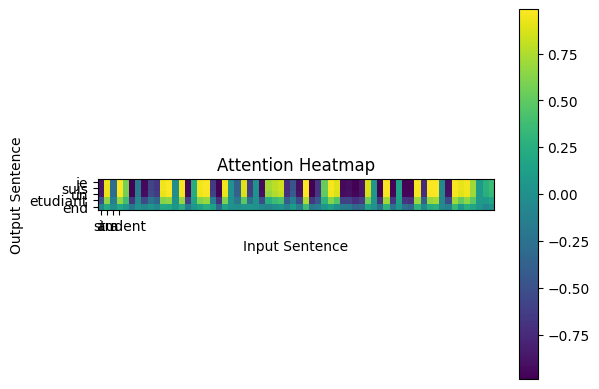

In [ ]:
# Pick sample
i = 0
enc_in = encoder_input[i:i+1]
dec_in = decoder_input[i:i+1]

att_weights = att_model.predict([enc_in, dec_in])[0]

input_words = input_texts[i].split()
target_words = target_texts[i].split()[1:]  # remove 'start'

plt.imshow(att_weights, cmap='viridis')
plt.xticks(range(len(input_words)), input_words)
plt.yticks(range(len(target_words)), target_words)
plt.xlabel("Input Sentence")
plt.ylabel("Output Sentence")
plt.title("Attention Heatmap")
plt.colorbar()
plt.show()